# Decision Trees

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/decision_trees.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Math Intuition](#2-math-intuition)
   - 2.1 How a Tree Splits
   - 2.2 Entropy and Information Gain
   - 2.3 Gini Impurity
   - 2.4 Entropy vs Gini — which to use?
   - 2.5 Regression Trees — Variance Reduction
   - 2.6 Stopping Criteria and Pruning
3. [Visual Intuition](#3-visual-intuition)
4. [Code from Scratch](#4-code-from-scratch)
5. [Sklearn Implementation](#5-sklearn-implementation)
6. [Common Mistakes](#6-common-mistakes)
7. [Exercises](#7-exercises)


## 1. Concept Overview

A decision tree splits data by asking a sequence of yes/no questions about features.
Each split divides the data into two groups — the tree keeps splitting until the leaves are pure (all one class) or a stopping condition is met.

**When to use it:**
- You need an interpretable model you can explain to non-technical people
- Mixed feature types (numeric and categorical)
- Non-linear relationships without needing feature engineering
- As a building block for ensemble methods (Random Forest, Gradient Boosting)

**Strengths:** Interpretable, handles missing values well, no scaling needed, captures non-linear boundaries

**Weaknesses:** Prone to overfitting, unstable (small data changes → very different tree), biased toward features with many unique values


## 2. Math Intuition

### 2.1 How a Tree Splits

At each node, the algorithm searches over **every feature** and **every possible split threshold** and picks the one that results in the **purest** child nodes.

For a dataset $D$ at a node, split on feature $j$ at threshold $t$:
- Left child:  $D_L = \{x \in D : x_j \leq t\}$
- Right child: $D_R = \{x \in D : x_j > t\}$

The **best split** maximizes the reduction in impurity:

$$\text{Gain}(D, j, t) = I(D) - \frac{|D_L|}{|D|} I(D_L) - \frac{|D_R|}{|D|} I(D_R)$$

where $I(\cdot)$ is an impurity measure (Entropy or Gini).

---

### 2.2 Entropy and Information Gain

**Entropy** measures the amount of disorder (uncertainty) in a set:

$$H(D) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

where $p_k$ is the fraction of samples in class $k$.

**Key values:**
- $H = 0$ when the node is **pure** (all samples belong to one class) — $p_k = 1$ for one class
- $H = 1$ when classes are **perfectly mixed** (50/50 binary) — maximum uncertainty
- $H = \log_2 K$ maximum for $K$ classes

**Worked example** — 10 samples: 6 class A, 4 class B:

$$H = -\frac{6}{10}\log_2\frac{6}{10} - \frac{4}{10}\log_2\frac{4}{10} = 0.971 \text{ bits}$$

**Information Gain** is the reduction in entropy after a split:

$$IG(D, j, t) = H(D) - \frac{|D_L|}{|D|} H(D_L) - \frac{|D_R|}{|D|} H(D_R)$$

The tree picks the split with the **highest information gain**.

---

### 2.3 Gini Impurity

Gini impurity measures the probability that a randomly chosen sample would be incorrectly classified by a randomly chosen label from the distribution:

$$G(D) = 1 - \sum_{k=1}^{K} p_k^2 = \sum_{k \neq j} p_k p_j$$

**Key values:**
- $G = 0$ when the node is pure
- $G = 0.5$ for a perfectly mixed binary node (maximum)
- $G = 1 - \frac{1}{K}$ maximum for $K$ classes

**Same worked example** — 6 class A, 4 class B:

$$G = 1 - \left(\frac{6}{10}\right)^2 - \left(\frac{4}{10}\right)^2 = 1 - 0.36 - 0.16 = 0.48$$

**Gini Gain** (used exactly like Information Gain):

$$\text{GiniGain}(D, j, t) = G(D) - \frac{|D_L|}{|D|} G(D_L) - \frac{|D_R|}{|D|} G(D_R)$$

---

### 2.4 Entropy vs Gini — Which to Use?

| | Entropy | Gini |
|---|---|---|
| **Computation** | Slower (involves log) | Faster (only squares) |
| **Behavior** | Penalizes impurity more strongly | Slightly smoother |
| **In practice** | Nearly identical results | Default in sklearn |
| **Sklearn param** | `criterion='entropy'` | `criterion='gini'` |

The choice rarely affects final accuracy significantly. Use Gini as the default.

---

### 2.5 Regression Trees — Variance Reduction

For regression, we replace impurity with **variance**. The best split minimizes the weighted variance of the children:

$$\text{VarGain}(D, j, t) = \text{Var}(D) - \frac{|D_L|}{|D|}\text{Var}(D_L) - \frac{|D_R|}{|D|}\text{Var}(D_R)$$

The prediction at each leaf is the **mean** of all training samples that fall into that leaf.

---

### 2.6 Stopping Criteria and Pruning

**Stopping criteria** (pre-pruning) — stop splitting when:
- `max_depth` reached
- `min_samples_split`: node has fewer than $n$ samples
- `min_samples_leaf`: a split would create a leaf with fewer than $n$ samples
- `min_impurity_decrease`: gain from the split is below a threshold

**Post-pruning** — grow a full tree, then prune branches that do not improve validation performance. Sklearn supports **cost-complexity pruning** via the `ccp_alpha` parameter.

Without stopping/pruning, the tree perfectly memorizes training data (zero training error) but generalizes poorly — a textbook case of overfitting.


## 3. Visual Intuition

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


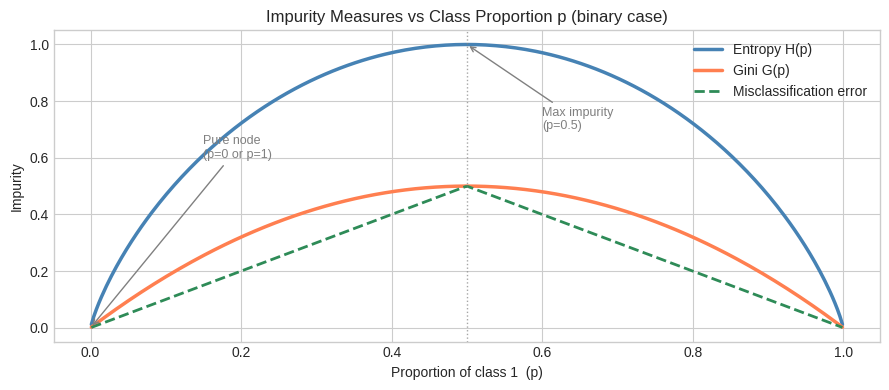

In [25]:
# ── Plot 1: Entropy and Gini as a function of class proportion ───────────────
p = np.linspace(0.001, 0.999, 300)

entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))
gini    = 1 - p**2 - (1-p)**2
misclass = 1 - np.maximum(p, 1-p)   # misclassification error (not used for splitting)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p, entropy,  color='steelblue', linewidth=2.5, label='Entropy H(p)')
ax.plot(p, gini,     color='coral',     linewidth=2.5, label='Gini G(p)')
ax.plot(p, misclass, color='seagreen',  linewidth=2,   label='Misclassification error', linestyle='--')

ax.axvline(0.5, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.set_title("Impurity Measures vs Class Proportion p (binary case)", fontsize=12)
ax.set_xlabel("Proportion of class 1  (p)")
ax.set_ylabel("Impurity")
ax.legend()
ax.annotate('Pure node\n(p=0 or p=1)', xy=(0, 0), xytext=(0.15, 0.6),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
ax.annotate('Max impurity\n(p=0.5)', xy=(0.5, entropy[150]), xytext=(0.6, 0.7),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

plt.tight_layout()
plt.show()


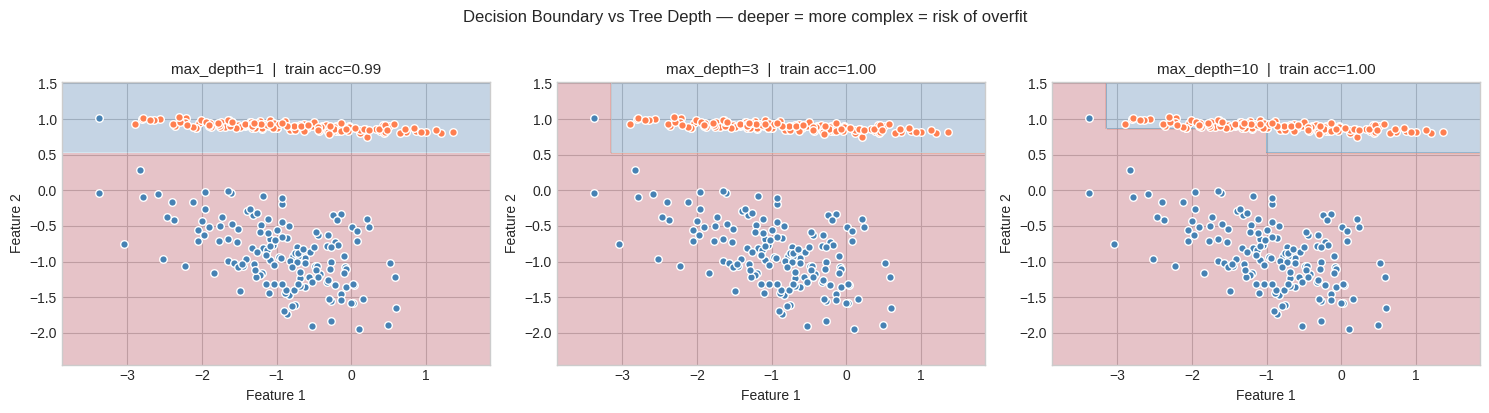

In [26]:
# ── Plot 2: How splits partition the feature space ───────────────────────────
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

X_vis, y_vis = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, random_state=5, n_clusters_per_class=1, class_sep=0.9
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
depths = [1, 3, 10]

for ax, depth in zip(axes, depths):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_vis, y_vis)

    # Decision boundary mesh
    h = 0.02
    x_min, x_max = X_vis[:,0].min()-0.5, X_vis[:,0].max()+0.5
    y_min, y_max = X_vis[:,1].min()-0.5, X_vis[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.scatter(X_vis[y_vis==0,0], X_vis[y_vis==0,1], c='steelblue',
               edgecolors='white', s=30, label='Class 0')
    ax.scatter(X_vis[y_vis==1,0], X_vis[y_vis==1,1], c='coral',
               edgecolors='white', s=30, label='Class 1')

    train_acc = clf.score(X_vis, y_vis)
    ax.set_title(f"max_depth={depth}  |  train acc={train_acc:.2f}", fontsize=11)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("Decision Boundary vs Tree Depth — deeper = more complex = risk of overfit",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


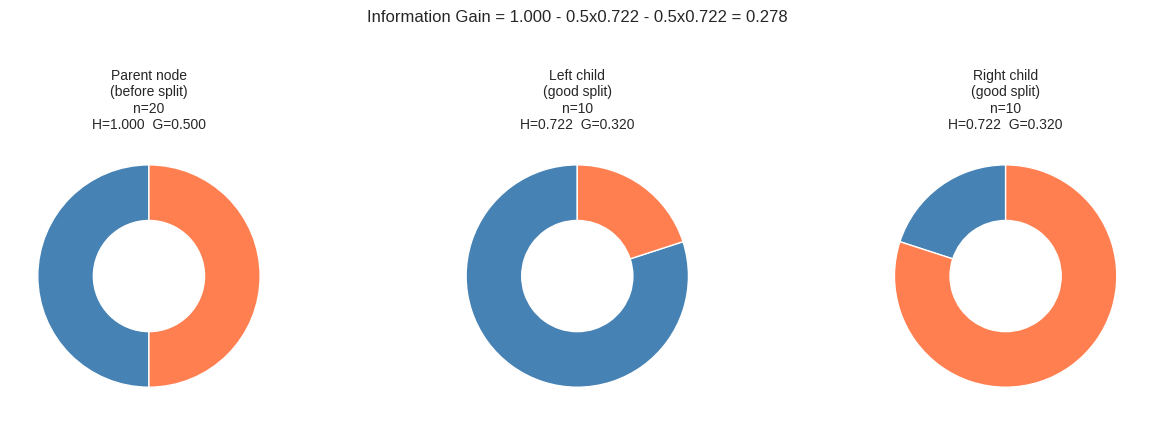

In [27]:
# ── Plot 3: Worked Information Gain calculation (visual) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

def draw_node(ax, counts, title, x=0.5, y=0.5, r=0.35):
    total = sum(counts)
    props = [c / total for c in counts]
    colors = ['steelblue', 'coral']
    labels = [f'Class {i}: {c}' for i, c in enumerate(counts)]

    wedges, _ = ax.pie(
        props,
        colors=colors,
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white')
    )
    H = -sum(p * np.log2(p) for p in props if p > 0)
    G = 1 - sum(p**2 for p in props)
    ax.set_title(f"{title}\nn={total}\nH={H:.3f}  G={G:.3f}", fontsize=10)

# Parent node: 10 class A, 10 class B
draw_node(axes[0], [10, 10], "Parent node\n(before split)")

# After split 1: left=8A,2B  right=2A,8B  -> good split
draw_node(axes[1], [8, 2], "Left child\n(good split)")
draw_node(axes[2], [2, 8], "Right child\n(good split)")

H_parent = 1.0
H_left = -(0.8 * np.log2(0.8) + 0.2 * np.log2(0.2))
H_right = -(0.2 * np.log2(0.2) + 0.8 * np.log2(0.8))
IG = H_parent - 0.5 * H_left - 0.5 * H_right

plt.suptitle(
    f"Information Gain = {H_parent:.3f} - 0.5x{H_left:.3f} - 0.5x{H_right:.3f} = {IG:.3f}",
    fontsize=12,
    y=1.05,
    )
plt.tight_layout()
plt.show()


## 4. Code from Scratch

In [28]:
class Node:
    """Represents a single node in the decision tree."""
    def __init__(self):
        # Split info (for internal nodes)
        self.feature_idx  = None
        self.threshold    = None
        self.left         = None
        self.right        = None
        # Prediction info (for leaf nodes)
        self.is_leaf      = False
        self.prediction   = None   # class label for classification
        self.impurity     = None


class DecisionTreeScratch:
    """
    Decision Tree Classifier built from scratch.
    Splitting criterion: Information Gain (Entropy).
    """

    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.root              = None
        self.n_classes_        = None

    # ── Impurity measures ────────────────────────────────────────────────────
    @staticmethod
    def _entropy(y):
        m = len(y)
        if m == 0:
            return 0.0
        counts = np.bincount(y)
        probs  = counts[counts > 0] / m
        return -np.sum(probs * np.log2(probs))

    def _information_gain(self, y, y_left, y_right):
        m      = len(y)
        m_l, m_r = len(y_left), len(y_right)
        return (self._entropy(y)
                - (m_l / m) * self._entropy(y_left)
                - (m_r / m) * self._entropy(y_right))

    # ── Find best split ──────────────────────────────────────────────────────
    def _best_split(self, X, y):
        best_gain      = -1
        best_feature   = None
        best_threshold = None

        n_features = X.shape[1]

        for feat in range(n_features):
            thresholds = np.unique(X[:, feat])
            # Use midpoints between consecutive unique values
            mid_thresholds = (thresholds[:-1] + thresholds[1:]) / 2

            for t in mid_thresholds:
                left_mask  = X[:, feat] <= t
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                gain = self._information_gain(y, y[left_mask], y[right_mask])

                if gain > best_gain:
                    best_gain      = gain
                    best_feature   = feat
                    best_threshold = t

        return best_feature, best_threshold, best_gain

    # ── Build tree recursively ───────────────────────────────────────────────
    def _build(self, X, y, depth):
        node = Node()
        node.impurity = self._entropy(y)

        # Stopping conditions
        pure      = len(np.unique(y)) == 1
        too_small = len(y) < self.min_samples_split
        too_deep  = (self.max_depth is not None) and (depth >= self.max_depth)

        if pure or too_small or too_deep:
            node.is_leaf    = True
            node.prediction = np.bincount(y, minlength=self.n_classes_).argmax()
            return node

        feat, threshold, gain = self._best_split(X, y)

        if feat is None or gain <= 0:
            node.is_leaf    = True
            node.prediction = np.bincount(y, minlength=self.n_classes_).argmax()
            return node

        left_mask = X[:, feat] <= threshold
        node.feature_idx  = feat
        node.threshold    = threshold
        node.left  = self._build(X[left_mask],  y[left_mask],  depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node

    # ── Public API ───────────────────────────────────────────────────────────
    def fit(self, X, y):
        self.n_classes_ = len(np.unique(y))
        self.root       = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.prediction
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


In [29]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_dt, y_dt = make_classification(
    n_samples=400, n_features=2, n_redundant=0,
    n_informative=2, random_state=42, n_clusters_per_class=1
)

X_tr, X_te, y_tr, y_te = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

# Train
tree = DecisionTreeScratch(max_depth=4, min_samples_split=5)
tree.fit(X_tr, y_tr)

print(f"Train accuracy: {tree.score(X_tr, y_tr):.4f}")
print(f"Test  accuracy: {tree.score(X_te, y_te):.4f}")


Train accuracy: 0.9250
Test  accuracy: 0.7500


In [30]:
# Verify against sklearn
from sklearn.tree import DecisionTreeClassifier

sk_tree = DecisionTreeClassifier(max_depth=4, min_samples_split=5,
                                  criterion='entropy', random_state=42)
sk_tree.fit(X_tr, y_tr)
print(f"Sklearn train accuracy: {sk_tree.score(X_tr, y_tr):.4f}")
print(f"Sklearn test  accuracy: {sk_tree.score(X_te, y_te):.4f}")
print("\nResults should be close (minor differences due to tie-breaking).")


Sklearn train accuracy: 0.9250
Sklearn test  accuracy: 0.7500

Results should be close (minor differences due to tie-breaking).


## 5. Sklearn Implementation

In [31]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# Load Iris for a clean multiclass example
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

clf = DecisionTreeClassifier(
    criterion='gini',        # 'gini' or 'entropy'
    max_depth=3,             # None = grow until pure
    min_samples_split=2,     # min samples to split a node
    min_samples_leaf=1,      # min samples in a leaf
    max_features=None,       # features to consider per split (None = all)
    random_state=42
)

clf.fit(X_tr_i, y_tr_i)
print(f"Train accuracy: {clf.score(X_tr_i, y_tr_i):.4f}")
print(f"Test  accuracy: {clf.score(X_te_i, y_te_i):.4f}")
print(f"\nTree depth: {clf.get_depth()}")
print(f"Number of leaves: {clf.get_n_leaves()}")


Train accuracy: 0.9833
Test  accuracy: 0.9667

Tree depth: 3
Number of leaves: 5


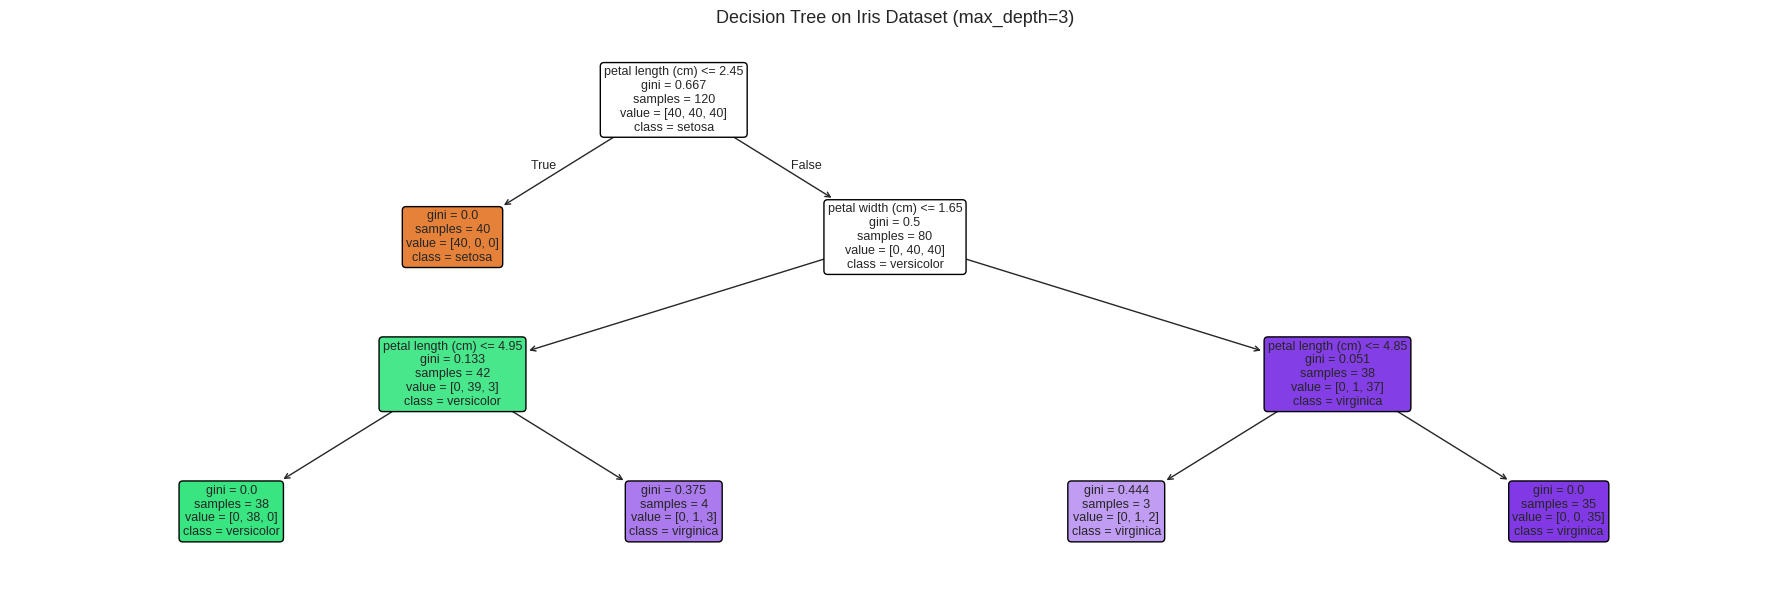


Text representation:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [32]:
# Visualize the tree
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(clf, feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree on Iris Dataset (max_depth=3)", fontsize=13)
plt.tight_layout()
plt.show()

# Text version — readable in any terminal
print("\nText representation:")
print(export_text(clf, feature_names=list(iris.feature_names)))


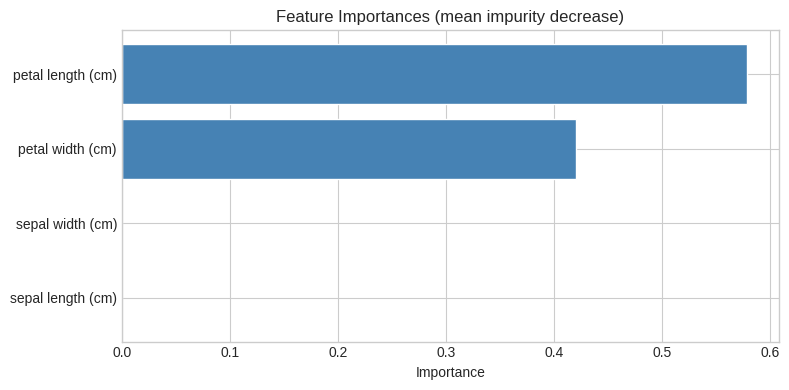

  petal length (cm)              0.5791
  petal width (cm)               0.4209
  sepal length (cm)              0.0000
  sepal width (cm)               0.0000


In [33]:
# Feature importances
importances = clf.feature_importances_
feat_names  = iris.feature_names

order = np.argsort(importances)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([feat_names[i] for i in order], importances[order],
        color='steelblue', edgecolor='white')
ax.set_title("Feature Importances (mean impurity decrease)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

for name, imp in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    print(f"  {name:<30} {imp:.4f}")


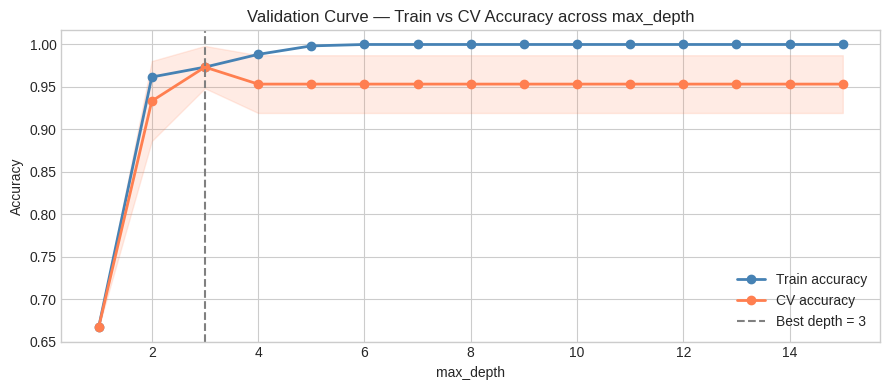

Best max_depth: 3  (CV accuracy: 0.9733)


In [34]:
# Validation curve — find the right max_depth
depths = range(1, 16)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_iris, y_iris,
    param_name='max_depth', param_range=depths,
    cv=5, scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_mean, 'o-', color='steelblue', linewidth=2, label='Train accuracy')
ax.plot(depths, val_mean,   'o-', color='coral',     linewidth=2, label='CV accuracy')
ax.fill_between(depths, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')

best_depth = depths[np.argmax(val_mean)]
ax.axvline(best_depth, color='gray', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_depth}')

ax.set_title("Validation Curve — Train vs CV Accuracy across max_depth")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best max_depth: {best_depth}  (CV accuracy: {val_mean[best_depth-1]:.4f})")


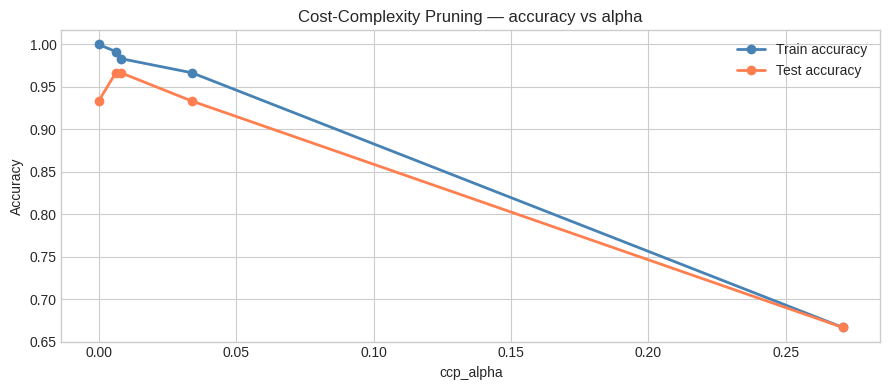

In [35]:
# Cost-complexity pruning (post-pruning)
path   = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_tr_i, y_tr_i)
alphas = path.ccp_alphas[:-1]   # exclude the trivial last one

train_scores_p, test_scores_p = [], []
for alpha in alphas:
    t = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    t.fit(X_tr_i, y_tr_i)
    train_scores_p.append(t.score(X_tr_i, y_tr_i))
    test_scores_p.append(t.score(X_te_i, y_te_i))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alphas, train_scores_p, 'o-', color='steelblue', linewidth=2, label='Train accuracy')
ax.plot(alphas, test_scores_p,  'o-', color='coral',     linewidth=2, label='Test accuracy')
ax.set_title("Cost-Complexity Pruning — accuracy vs alpha")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Common Mistakes

In [36]:
# MISTAKE 1: Growing a tree without max_depth — instant overfit
X_m, y_m = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                 random_state=7, n_clusters_per_class=1)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(X_m, y_m, test_size=0.3, random_state=0)

print(f"{'max_depth':<12}  {'Train acc':>10}  {'Test acc':>10}  {'Leaves':>8}")
for d in [None, 10, 5, 3, 2]:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_m_tr, y_m_tr)
    print(f"{str(d):<12}  {t.score(X_m_tr, y_m_tr):10.4f}  {t.score(X_m_te, y_m_te):10.4f}  {t.get_n_leaves():8d}")

print("\nUnlimited depth (None) memorizes training data — test accuracy drops.")


max_depth      Train acc    Test acc    Leaves
None              1.0000      0.9889         7
10                1.0000      0.9889         7
5                 1.0000      0.9889         7
3                 0.9905      0.9889         5
2                 0.9905      0.9889         3

Unlimited depth (None) memorizes training data — test accuracy drops.


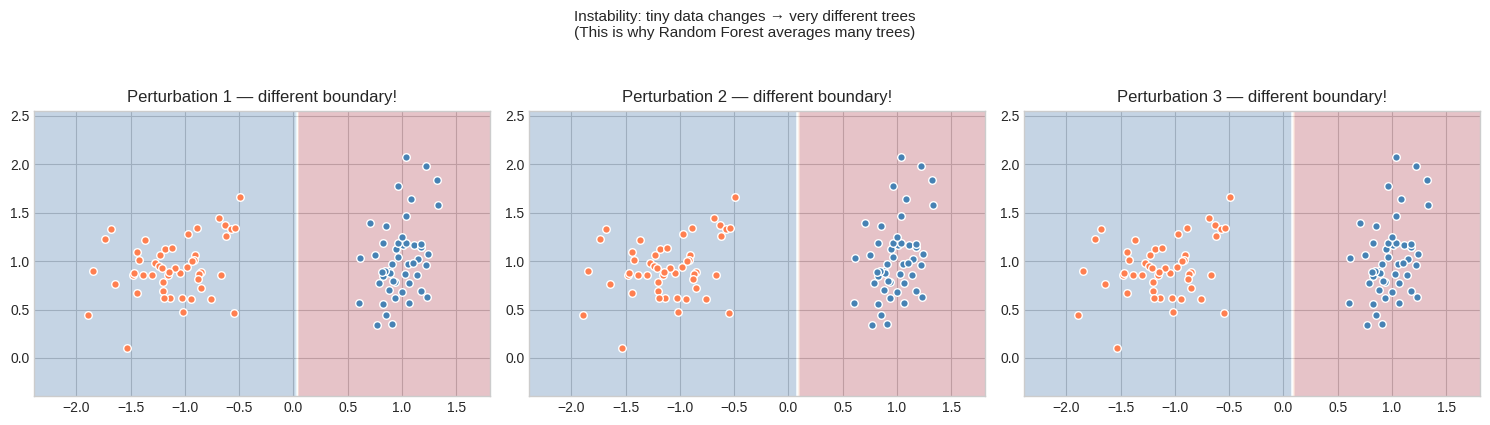

In [37]:
# MISTAKE 2: Decision trees are unstable — small data change → very different tree
rng2 = np.random.default_rng(0)
X_s, y_s = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                 random_state=1, n_clusters_per_class=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    # Slightly perturb data
    X_perturbed = X_s + rng2.normal(0, 0.05, X_s.shape)
    t = DecisionTreeClassifier(max_depth=3, random_state=i)
    t.fit(X_perturbed, y_s)

    h = 0.05
    xx, yy = np.meshgrid(np.arange(X_s[:,0].min()-0.5, X_s[:,0].max()+0.5, h),
                         np.arange(X_s[:,1].min()-0.5, X_s[:,1].max()+0.5, h))
    Z = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.scatter(X_s[y_s==0,0], X_s[y_s==0,1], c='steelblue', s=30, edgecolors='white')
    ax.scatter(X_s[y_s==1,0], X_s[y_s==1,1], c='coral',     s=30, edgecolors='white')
    ax.set_title(f"Perturbation {i+1} — different boundary!")

plt.suptitle("Instability: tiny data changes → very different trees\n(This is why Random Forest averages many trees)",
             fontsize=11, y=1.05)
plt.tight_layout()
plt.show()


In [38]:
# MISTAKE 3: Feature importances can be misleading with high-cardinality features
# Features with many unique values get inflated importance scores
# because the tree has more split thresholds to choose from.

# Safe alternative: use permutation importance from sklearn.inspection
from sklearn.inspection import permutation_importance

clf_imp = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_imp.fit(X_tr_i, y_tr_i)

perm_imp = permutation_importance(clf_imp, X_te_i, y_te_i, n_repeats=20, random_state=42)

print("Permutation Importance (more reliable than .feature_importances_):")
for name, mean, std in sorted(
        zip(iris.feature_names, perm_imp.importances_mean, perm_imp.importances_std),
        key=lambda x: -x[1]):
    print(f"  {name:<30} {mean:.4f} ± {std:.4f}")


Permutation Importance (more reliable than .feature_importances_):
  petal length (cm)              0.4750 ± 0.0875
  petal width (cm)               0.1017 ± 0.0553
  sepal width (cm)               0.0117 ± 0.0159
  sepal length (cm)              -0.0167 ± 0.0167


## 7. Exercises

**Exercise 1:** Compute Information Gain manually for the following split and verify your answer matches the formula.

- Parent: 10 samples — 5 class A, 5 class B
- Left child: 4 samples — 4 class A, 0 class B
- Right child: 6 samples — 1 class A, 5 class B


In [39]:
# Your code here


In [40]:
# Solution
def entropy(counts):
    total = sum(counts)
    if total == 0: return 0.0
    probs = [c/total for c in counts if c > 0]
    return -sum(p * np.log2(p) for p in probs)

H_parent = entropy([5, 5])
H_left   = entropy([4, 0])
H_right  = entropy([1, 5])

m, m_l, m_r = 10, 4, 6
IG = H_parent - (m_l/m)*H_left - (m_r/m)*H_right

print(f"H(parent)  = {H_parent:.4f}")
print(f"H(left)    = {H_left:.4f}  (pure node)")
print(f"H(right)   = {H_right:.4f}")
print(f"IG         = {H_parent:.4f} - ({m_l}/{m})*{H_left:.4f} - ({m_r}/{m})*{H_right:.4f}")
print(f"IG         = {IG:.4f}")


H(parent)  = 1.0000
H(left)    = -0.0000  (pure node)
H(right)   = 0.6500
IG         = 1.0000 - (4/10)*-0.0000 - (6/10)*0.6500
IG         = 0.6100


**Exercise 2:** Add Gini impurity as an alternative criterion to `DecisionTreeScratch`. Add a `criterion` parameter (`'entropy'` or `'gini'`) and confirm both produce similar accuracy on the same dataset.


In [41]:
# Your code here


In [42]:
# Solution
class DecisionTreeScratchV2(DecisionTreeScratch):
    def __init__(self, max_depth=None, min_samples_split=2, criterion='gini'):
        super().__init__(max_depth, min_samples_split)
        self.criterion = criterion

    @staticmethod
    def _gini(y):
        m = len(y)
        if m == 0: return 0.0
        counts = np.bincount(y)
        probs  = counts / m
        return 1 - np.sum(probs**2)

    def _impurity(self, y):
        return self._entropy(y) if self.criterion == 'entropy' else self._gini(y)

    def _information_gain(self, y, y_left, y_right):
        m = len(y)
        return (self._impurity(y)
                - (len(y_left)/m)  * self._impurity(y_left)
                - (len(y_right)/m) * self._impurity(y_right))

print(f"{'Criterion':<10}  {'Train acc':>10}  {'Test acc':>10}")
for crit in ['entropy', 'gini']:
    t = DecisionTreeScratchV2(max_depth=4, criterion=crit)
    t.fit(X_tr, y_tr)
    print(f"{crit:<10}  {t.score(X_tr, y_tr):10.4f}  {t.score(X_te, y_te):10.4f}")


Criterion    Train acc    Test acc
entropy         0.9250      0.7500
gini            0.9281      0.7750


**Exercise 3:** Use `GridSearchCV` to find the best combination of `max_depth`, `min_samples_split`, and `criterion` on the Iris dataset. Report the best parameters and the best cross-validated accuracy.


In [43]:
# Your code here


In [44]:
# Solution
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':        [2, 3, 4, 5, None],
    'min_samples_split':[2, 5, 10],
    'criterion':        ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_iris, y_iris)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")
print(f"\nTop 5 parameter combinations:")
results = grid.cv_results_
top5_idx = np.argsort(results['mean_test_score'])[-5:][::-1]
for i in top5_idx:
    print(f"  {results['params'][i]}  →  {results['mean_test_score'][i]:.4f}")


Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV accuracy: 0.9733

Top 5 parameter combinations:
  {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}  →  0.9733
  {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}  →  0.9733
  {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 5}  →  0.9733
  {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}  →  0.9667
  {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5}  →  0.9667


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
